#Практическая работа №2

**Цель работы:** использовать логистическую регрессию и методы опорных векторов на обработанных в первой работе данных, оценить и сравнить качество этих классификаторов.

**Задачи работы:**

1. Обработать данные, полученные в первой работе: проверить на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной. Сделать анализ и обработку так, чтобы получить максимальную точность.
2. Обучить и оценить логистическую регрессию, обосновать выбор конкретного метода.
3. Обучить и оценить методы опорных векторов (выбрать ядро и обосновать выбор).
4. Провести ручную настройку гиперпараметров (несколько экспериментов) и объяснить, как это повлияло на метрики.
5. Оценить модели по метрикам качества (Accuracy и F1).
6. Сделать выводы по каждому алгоритму и общий вывод.

**Используемые алгоритмы:**

1. **Логистическая регрессия:** модель вычисляет взвешенную сумму признаков и прогоняет через сигмоиду. Делится на три типа: биноминальная, мультиномиальная, порядковая. Для этой задачи актуальна биномиальная логистическая регрессия, потому что целевая переменная — бинарная. Для использования важно: независимость признаков, линейная связь между признаками и предиктом, отсутствие выбросов, большое количество данных. Ключевые гиперпараметры: тип регуляризации (L1/L2), сила регуляризации C (обратная к λ), solver (алгоритм оптимизации), class_weight (для борьбы с дисбалансом). Функция потерь логарифмическая (log-loss), обычно добавляют регуляризацию (L1 или L2).
2. **Метод опорных векторов (SVM):** пытается найти разделяющую гиперплоскость, которая максимизирует зазор (margin) между классами. Существует 2 вида вариации метода опорных векторов: SVC метод опорных векторов для классификации, SVR метод опорных векторов для регрессии. Для каждого из вариаций есть ядра: линейное, полиномиальное ядро, радиально - базисное. Важные гиперпараметры: C (штраф за ошибки), kernel (ядро), gamma (ширина ядра, отвечающая за вид границы), degree (степень полиномиального ядра), class_weight (веса классов).
3. **Метрики качества:** Accuracy — доля правильных предсказаний, F1-score — гармоническое среднее precision и recall (лучше отражает качество при дисбалансе классов).

Датасет: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

Практическая работа №1: https://www.google.com/url?q=https://colab.research.google.com/drive/18Q3VaG4-zlDW4fyuT2ItsGs8L6pHxBzd?usp%3Dsharing&sa=D&source=editors&ust=1758898607971533&usg=AOvVaw2svt24-5qSjZyjOS7gAPCv

In [ ]:
# Используемые библиотеки
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC


## 1. Загрузка и анализ данных

In [ ]:
# Загрузка обработанных ранее данных

!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train2.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val2.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test2.pkl

X_train, y_train = joblib.load("train2.pkl")
X_val, y_val = joblib.load("val2.pkl")
X_test, y_test = joblib.load("test2.pkl")

# Объединим train и val для общего анализа
X = pd.concat([X_train, X_val], axis=0)
y = pd.concat([y_train, y_val], axis=0)

In [ ]:
X.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
26038,2014-05-24,-0.246478,0.234988,-0.279738,-0.130206,0.173575,-1.514386,-1.129448,-2.135615,-0.043681,...,False,False,False,False,False,False,False,False,False,False
83712,2016-09-04,-0.966195,-1.141465,-0.086900,-0.829694,-0.664637,0.084034,0.115550,0.613364,1.327416,...,False,False,False,False,False,False,False,False,False,False
12822,2011-01-26,1.943963,2.552485,-0.279738,2.211556,1.640447,-0.677118,0.681458,-0.875666,-0.940167,...,False,False,False,False,False,False,False,False,False,False
59778,2013-08-22,-1.326053,-1.492601,0.515718,-1.133819,0.173575,0.084034,0.115550,0.040660,1.380150,...,False,False,False,False,False,False,False,False,False,False
78980,2011-10-19,-0.715858,0.656351,-0.279738,0.873406,1.535670,1.073531,-0.563540,0.384282,-0.623761,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
y.head()

,RainTomorrow
26038,0
83712,0
12822,0
59778,1
78980,0


In [ ]:
# Сбросим индексы для более понятного отображения
y = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
X = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

In [ ]:
X.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,2014-05-24,-0.246478,0.234988,-0.279738,-0.130206,0.173575,-1.514386,-1.129448,-2.135615,-0.043681,...,False,False,False,False,False,False,False,False,False,False
1,2016-09-04,-0.966195,-1.141465,-0.086900,-0.829694,-0.664637,0.084034,0.115550,0.613364,1.327416,...,False,False,False,False,False,False,False,False,False,False
2,2011-01-26,1.943963,2.552485,-0.279738,2.211556,1.640447,-0.677118,0.681458,-0.875666,-0.940167,...,False,False,False,False,False,False,False,False,False,False
3,2013-08-22,-1.326053,-1.492601,0.515718,-1.133819,0.173575,0.084034,0.115550,0.040660,1.380150,...,False,False,False,False,False,False,False,False,False,False
4,2011-10-19,-0.715858,0.656351,-0.279738,0.873406,1.535670,1.073531,-0.563540,0.384282,-0.623761,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
y.head()

,RainTomorrow
0,0
1,0
2,0
3,1
4,0


Преобразуем также признак Date с типом datetime в числовой формат, так как модели, которые будут использоваться далее, не умеют работать с датами напрямую.

In [ ]:
for df in [X, X_test]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df.drop(columns=['Date'], inplace=True)

X.head()


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
0,-0.246478,0.234988,-0.279738,-0.130206,0.173575,-1.514386,-1.129448,-2.135615,-0.043681,-0.218721,...,False,False,False,False,False,False,False,2014,5,24
1,-0.966195,-1.141465,-0.086900,-0.829694,-0.664637,0.084034,0.115550,0.613364,1.327416,1.240866,...,False,False,False,False,False,False,False,2016,9,4
2,1.943963,2.552485,-0.279738,2.211556,1.640447,-0.677118,0.681458,-0.875666,-0.940167,-1.337739,...,False,False,False,False,False,False,False,2011,1,26
3,-1.326053,-1.492601,0.515718,-1.133819,0.173575,0.084034,0.115550,0.040660,1.380150,0.948949,...,False,False,False,False,False,False,False,2013,8,22
4,-0.715858,0.656351,-0.279738,0.873406,1.535670,1.073531,-0.563540,0.384282,-0.623761,-0.753904,...,False,False,True,False,False,False,False,2011,10,19


### Проверка дисбаланса классов

Посмотрим, насколько равномерно распределены классы в целевой переменной `RainTomorrow`. Если один класс сильно преобладает, модели могут быть смещены в его сторону, поэтому важно учитывать дисбаланс и использовать метрики, чувствительные к редким классам (например f1-score).


Распределение классов:
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


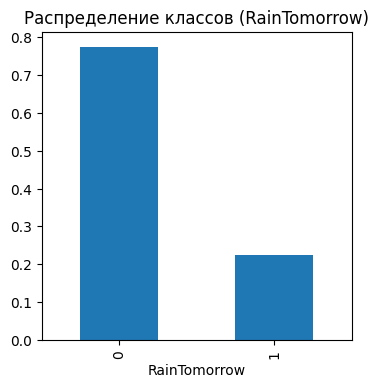

In [ ]:
# Доля классов
class_counts = y.value_counts(normalize=True)
print("Распределение классов:")
print(class_counts)

# Визуализация
plt.figure(figsize=(4,4))
class_counts.plot(kind='bar')
plt.title("Распределение классов (RainTomorrow)")
plt.show()

Распределение классов неравномерное: большинство наблюдений класс 0 (без дождя), а 1 (дождь) встречается реже.
При обучении моделей нужно будет учитывать этот дисбаланс.


### Корреляция признаков

Посмотрим, какие признаки сильно связаны друг с другом. Сильная корреляция может создавать избыточность информации, а в некоторых моделях, таких как линейная регрессия, мультиколлинеарность.


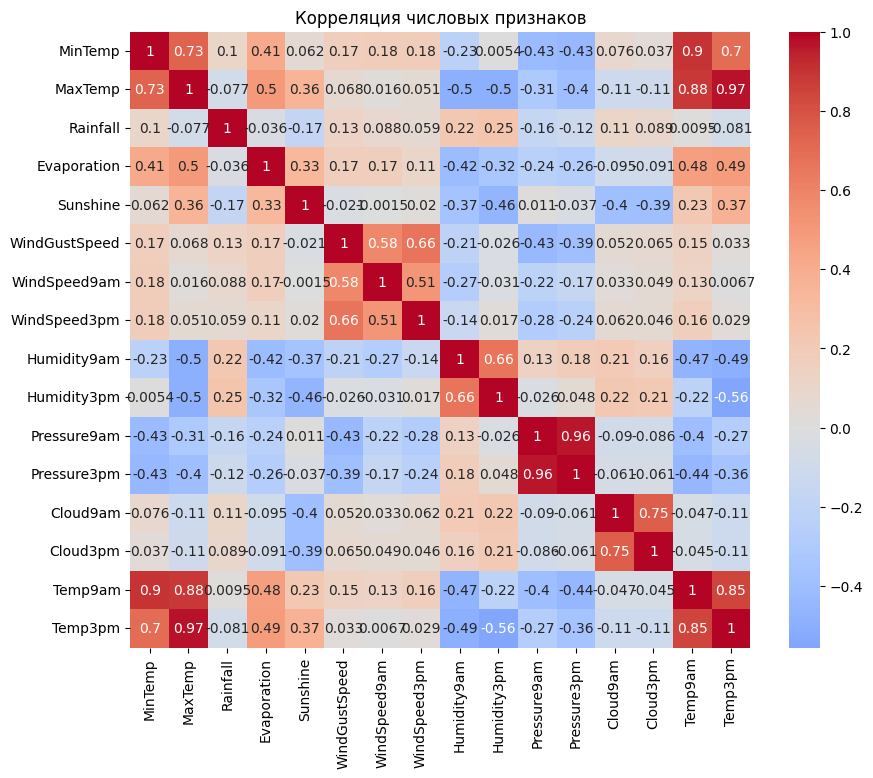

In [ ]:
# Выбираем только числовые признаки
numeric_features = X.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_features.corr(), cmap="coolwarm", center=0, annot=True)
plt.title("Корреляция числовых признаков")
plt.show()

Сильная корреляция обнаружена между признаками:
- Температур: MinTemp, MaxTemp, Temp9am, Temp3pm
- Давления: Pressure3pm, Pressure9am
- Облачности: Cloud3pm, Cloud9am

Это означает, что многие признаки несут почти одинаковую информацию. Для моделей, чувствительных к мультиколлинеарности (например, логистическая регрессия), лучше оставить только часть признаков.

У признаков ветра и влажности корреляция умеренная, не выше 0.66, поэтому я оставлю все эти признаки.


Теперь посмотрим корреляцию признаков с целевой переменной и на основе этого выберем, какие из сильно коррелирующих между собой признаков оставить.

In [ ]:
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
corr_with_target = X[numeric_features].apply(lambda x: x.corr(y))
corr_with_target.sort_values(ascending=False)

,0
Humidity3pm,0.438778
Humidity9am,0.254793
Rainfall,0.237478
WindGustSpeed,0.223927
Cloud3pm,0.174630
Cloud9am,0.155882
WindSpeed9am,0.091339
WindSpeed3pm,0.087951
MinTemp,0.083811
Temp9am,-0.025347


На основе анализа корреляции между числовыми признаками и их связи с целевой переменной можно удалить следующие:

- MinTemp, MaxTemp, Temp9am: сильно коррелируют между собой и с Temp3pm, а Temp3pm имеет наибольшую по модулю корреляцию с целевой переменной, поэтому оставляю только Temp3pm.
- Pressure3pm: высокая корреляция с Pressure9am, при этом Pressure9am имеет чуть более сильную связь с целевой переменной.
- Cloud9am: высокая корреляция с Cloud3pm, Cloud3pm имеет чуть более высокую корреляцию с целевой переменной, поэтому оставляю только его.

Удаление этих признаков позволит уменьшить дублирование информации и снизить мультиколлинеарность, не потеряв значимой информации для моделей.


In [ ]:
# Список признаков для удаления
features_to_drop = ['MinTemp', 'MaxTemp', 'Temp9am', 'Pressure3pm', 'Cloud9am']

# Удаляем из X
X_reduced = X.drop(columns=features_to_drop)

X_reduced.head()

,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
0,-0.279738,-0.130206,0.173575,-1.514386,-1.129448,-2.135615,-0.043681,-0.218721,-0.007464,-1.138593,...,False,False,False,False,False,False,False,2014,5,24
1,-0.086900,-0.829694,-0.664637,0.084034,0.115550,0.613364,1.327416,1.240866,0.792987,-1.138593,...,False,False,False,False,False,False,False,2016,9,4
2,-0.279738,2.211556,1.640447,-0.677118,0.681458,-0.875666,-0.940167,-1.337739,-0.733800,-0.828984,...,False,False,False,False,False,False,False,2011,1,26
3,0.515718,-1.133819,0.173575,0.084034,0.115550,0.040660,1.380150,0.948949,-0.941324,1.338278,...,False,False,False,False,False,False,False,2013,8,22
4,-0.279738,0.873406,1.535670,1.073531,-0.563540,0.384282,-0.623761,-0.753904,1.326621,-0.828984,...,False,False,True,False,False,False,False,2011,10,19


После удаления сильно коррелирующих и менее информативных признаков размерность данных уменьшилась, а оставшиеся признаки сохраняют максимальную информативность относительно целевой переменной.  
Теперь набор данных готов к дальнейшему построению моделей машинного обучения с меньшей мультиколлинеарностью и без потери ключевой информации.


Тестовую выборку я не объединяла с обучающей, чтобы она оставалась независимой, но для корректного обучения и оценки модели в тестовой выборке нужно удалить те же признаки, что убраны в train и val.


In [ ]:
# Список признаков для удаления
features_to_drop = ['MinTemp', 'MaxTemp', 'Temp9am', 'Pressure3pm', 'Cloud9am']

# Удаляем из тестовой выборки
X_test_reduced = X_test.drop(columns=features_to_drop)

X_test_reduced.head()

,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
106906,-0.279738,1.968256,0.557756,1.758568,2.379183,1.873312,-1.414778,-1.678309,-0.037111,-1.138593,...,False,False,False,False,False,False,True,2012,10,6
127803,0.178252,-0.130206,0.173575,-0.677118,-0.789903,-1.104748,1.432885,2.311231,-1.341550,-1.138593,...,False,True,False,False,False,False,False,2011,10,2
25835,-0.279738,-0.130206,0.173575,0.236264,-1.129448,0.155201,0.272726,-2.164838,-0.007464,-1.138593,...,False,False,False,False,False,False,False,2013,11,2
90081,4.444792,0.325981,-0.315382,-0.372657,0.115550,0.384282,0.589133,0.559725,-0.644861,1.338278,...,False,False,False,False,False,False,False,2017,1,18
5624,-0.255633,-0.130206,0.173575,-0.753234,-1.582174,0.040660,1.643823,-0.316027,1.534146,-1.138593,...,False,False,False,False,False,False,False,2016,4,27


### Визуализация

Можно также попробовать построить pairplot для нескольких признаков с наибольшей корреляцией с целевой переменной `RainTomorrow`. На диагонали графика показаны распределения признаков в зависимости от целевого значения (дождь/нет дождя), а вне диагонали — попарные зависимости между признаками, где цвет точек указывает на класс.


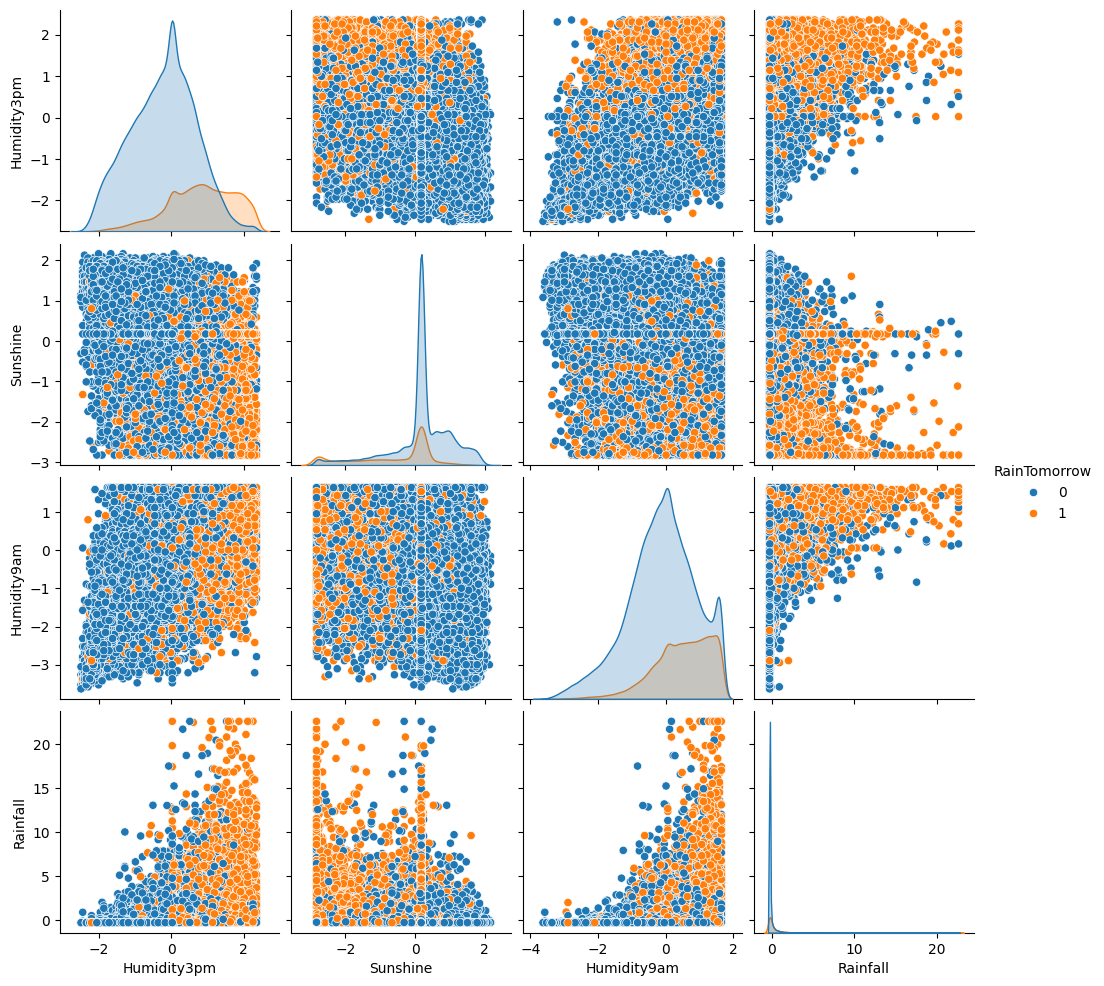

In [ ]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(4).index.tolist()

sns.pairplot(pd.concat([X[top_features], y], axis=1), hue="RainTomorrow", diag_kind="kde")
plt.show()




На диагонали видно, что распределение каждого признака для класса 0 выше, чем для класса 1, что связано с дисбалансом классов: дождливых дней меньше, поэтому распределение смещено. На парных scatterplot заметно, что при высокой влажности или низком солнце вероятность дождя значительно выше. Также наблюдается не очень четкое, но заметное общее разделение точек разных классов: в отдельных областях преобладают либо "сухие", либо "дождливые" дни.



## 3. Логистическая регрессия

*Для работы с моделями категориальные признаки были закодированы методом one-hot, что значительно увеличило количество признаков до 108. При попытке работы с таким количеством данных и признаков я столкнулась с проблемой очень долгого обучения моделей, и если с логистической регрессией удалось выполнить все задачи, модель SVM обучалась слишком долго. Поэтому я решила удалить признаки 'WindGustDir', 'WindDir9am', 'WindDir3pm', требующие one-hot кодирование, и оставить только 'Location', как признак имеющий наибольшее влияние на целевую переменную (показано в первой работе). Три удаленных признака также имели влияние на целевую переменную, но я не придумала, как сделать по-другому. В этоге количество признаков снизилось с 108 до 63 и время выполнения сильно уменьшилось, но метрики ожидаемо немного ухудшились.*

Обучим модель логистической регрессии.  
Этот метод является базовой моделью для бинарной классификации и хорошо подходит для задачи предсказания дождя (`RainTomorrow`). Логистическая регрессия чувствительна к мультиколлинеарности признаков, поэтому предварительно был проведён анализ корреляции и удалены сильно коррелирующие признаки. Модель даёт не только предсказания классов, но и оценку вероятностей.  

In [ ]:
# Делим объединённую выборку обратно на тестовую и валидационную
X_train, X_val, y_train, y_val = train_test_split(
    X_reduced, y,
    test_size=0.2,  # 20% под валидацию
    random_state=42,
    stratify=y  # важно при дисбалансе классов, чтобы соотношение классов в train и val было примерно такое же, как в исходных данных
)

print("Train size:", X_train.shape, y_train.shape)
print("Val size:", X_val.shape, y_val.shape)
print("Test size:", X_test_reduced.shape, y_test.shape)


Train size: (96691, 63) (96691,)
Val size: (24173, 63) (24173,)
Test size: (21329, 63) (21329,)


Обучим модель логистической регрессии на подготовленных данных:  
- обучение — на `X_train`,  
- проверка гиперпараметров — на `X_val`,  
- финальная оценка — на `X_test_reduced`.

**Выбор метода логистической регрессии**

Для данной задачи бинарной классификации (`RainTomorrow`: дождь/не дождь) я использую биноминальную логистическую регрессию. Это наиболее подходящий метод для моей задачи, так как целевая переменная имеет только два значения (0 — нет дождя, 1 — дождь).


In [ ]:
# Обучение модели
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # учитываем дисбаланс классов
    multi_class='ovr',        # указываем биноминальный метод
    random_state=42
)
log_reg.fit(X_train, y_train)

# Проверка на валидации
y_val_pred = log_reg.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation results:")
print(f"Accuracy: {val_acc:.4f}")
print(f"F1-score: {val_f1:.4f}")

# Оценка на тестовой выборке
y_test_pred = log_reg.predict(X_test_reduced)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTest results:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation results:
Accuracy: 0.7837
F1-score: 0.6108

Test results:
Accuracy: 0.7894
F1-score: 0.6212

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.85     16548
           1       0.52      0.77      0.62      4781

    accuracy                           0.79     21329
   macro avg       0.72      0.78      0.74     21329
weighted avg       0.83      0.79      0.80     21329



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Анализ результатов логистической регрессии**

- Accuracy ~0.79: модель правильно предсказывает около 79% случаев в целом.
- F1-score класса 1 (дождь) = 0.62: ниже, чем для класса 0 (0.85), что ожидаемо при дисбалансе классов.
- Recall класса 1 = 0.77, Precision = 0.52: модель чаще угадывает дождь (высокий recall), но делает много ложноположительных предсказаний (низкий precision).
- В целом F1-score macro avg = 0.74: среднее качество предсказаний по обоим классам.

Основная метрика для оценки модели в этом случае — F1 для класса дождя. Accuracy тоже полезна для общей оценки, но не отражает качество редкого класса, может быть высокой просто потому, что модель часто предсказывает "не будет дождя".

В целом, модель обеспечивает базовый уровень предсказаний, но дисбаланс классов всё ещё влияет на точность предсказания.

*Метрики, полученные для 108 признаков, были такие:*

*Validation results:*
Accuracy: 0.7876
F1-score: 0.6164

*Test results:*
Accuracy: 0.7929
F1-score: 0.6239

*Classification report:*



               precision    recall  f1-score   support

           0       0.92      0.80      0.86     16548
           1       0.53      0.77      0.62      4781

    accuracy                           0.79     21329
    macro avg       0.72      0.78      0.74     21329
    weighted avg       0.83      0.79      0.80     21329


Построим матрицу ошибок для более наглядного анализа распределения ошибок между классами.

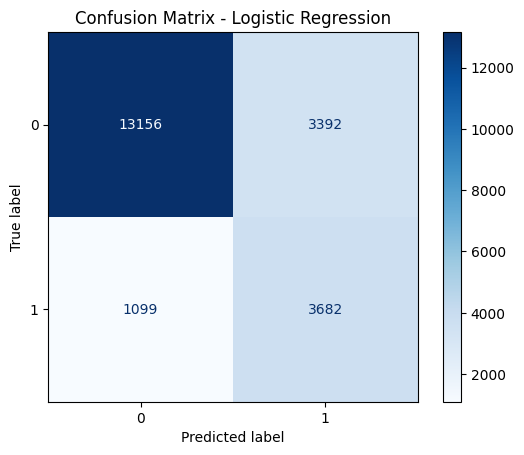

In [ ]:
# Предсказания на тестовой выборке
y_test_pred = log_reg.predict(X_test_reduced)

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


13156 (True Negatives) — модель правильно предсказала «нет дождя».

3392 (False Positives) — модель ошибочно предсказала дождь, хотя его не было.

1099 (False Negatives) — модель не предсказала дождь, хотя дождь был.

3682 (True Positives) — модель правильно предсказала дождь.

Модель лучше распознаёт отсутствие дождя, чем наличие дождя (что ожидаемо при дисбалансе классов). В целом модель адекватно разделяет классы, но нужно улучшить precision для класса дождя, чтобы меньше было ложных предупреждений.

*Для 108 признаков была такая:*

*13246 (True Negatives), 3302 (False Positives), 1116 (False Negatives), 3665 (True Positives)*

**Подбор гиперпараметров логистической регрессии**

Для логистической регрессии основными гиперпараметрами являются:  

- `C` — обратная сила регуляризации. Меньшее значение - сильная регуляризация, большее - слабее регуляризация.  
- `penalty` — тип регуляризации (L1 или L2).  

Попробуем разные комбинации этих параметров и оценим метрики на валидационной выборке, чтобы понять, как они влияют на точность и F1-score. Затем лучшие из найденных параметров применим к тестовой выборке.

Тестовая выборка не используется при подборе гиперпараметров, чтобы сохранить её как независимую для финальной оценки модели.


In [ ]:
# Берем половину тренировочной выборки для ускоренного подбора
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.5,
    stratify=y_train,
    random_state=42
)

# Список вариантов гиперпараметров
C_values = [0.1, 1, 10]
penalties = ['l1', 'l2']

results = []

for C in C_values:
    for penalty in penalties:
        try:
            model = LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                C=C,
                penalty=penalty,
                solver='saga',        # нужен для L1
                multi_class='ovr',
                random_state=42
            )
            model.fit(X_train_small, y_train_small)
            y_val_pred = model.predict(X_val)
            acc = accuracy_score(y_val, y_val_pred)
            f1 = f1_score(y_val, y_val_pred)
            results.append({'C': C, 'penalty': penalty, 'accuracy': acc, 'f1': f1})
        except Exception as e:
            results.append({'C': C, 'penalty': penalty, 'accuracy': None, 'f1': None})

results_df = pd.DataFrame(results)
results_df.sort_values(by='f1', ascending=False) # Сортируем по лучшему значению f1

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_

,C,penalty,accuracy,f1
2,1.0,l1,0.779961,0.605562
1,0.1,l2,0.779920,0.605458
4,10.0,l1,0.779920,0.605458
3,1.0,l2,0.779920,0.605458
5,10.0,l2,0.779920,0.605458
0,0.1,l1,0.779589,0.605041


После ручного подбора гиперпараметров были проверены разные значения коэффициента регуляризации C и типов регуляризации penalty (L1 и L2).

Основные наблюдения:

Различия в метриках минимальны: F1-score колеблется в пределах 0.6050–0.6055, точность около 0.779.

Лучшая комбинация на валидационной выборке: C=1.0, penalty='l1'. Однако с  penalty='l1' значительно возрастает время выполнения, поэтому для проверки на тестовой выборке я буду использовать вторую лучшую комбинацию C=0.1, penalty='l2', различия в значениях метрик у них минимальные.

Предупреждение о сходимости (ConvergenceWarning) появляется из-за того, что алгоритм не полностью сошелся за 1000 итераций. Но модель показывает приемлемое качество, поэтому добиваться сходимости не буду.

Для получения итоговой модели объединяем тренировочную и валидационную выборки, обучаем модель на всей объединённой выборке с найденными гиперпараметрами и проверяем её качество на тестовой выборке.



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Test Accuracy: 0.7892
Test F1-score: 0.6208

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     16548
           1       0.52      0.77      0.62      4781

    accuracy                           0.79     21329
   macro avg       0.72      0.78      0.74     21329
weighted avg       0.83      0.79      0.80     21329



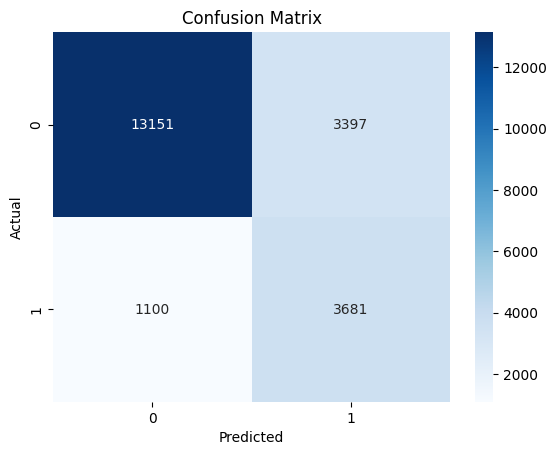

In [ ]:
# Объединяем тренировочную и валидационную выборки
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

# Обучение модели
final_log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,
    penalty='l2',
    random_state=42
)
final_log_reg.fit(X_train_full, y_train_full)

# Предсказания на тестовой выборке
y_test_pred = final_log_reg.predict(X_test_reduced)

# Метрики качества
acc_test = accuracy_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test F1-score: {f1_test:.4f}")

# Отчёт
print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Повторно обучили модель логистической регрессии с гиперпараметрами, подобранными вручную.

**Результаты на тестовой выборке:**
- Accuracy: **0.7892**  
- F1-score: **0.6208**

Метрики практически совпадают с результатами базовой модели, но все же стали немного лучше.  

Таким образом, логистическая регрессия демонстрирует стабильные результаты, и её можно использовать в качестве базовой модели для сравнения с более сложными алгоритмами, например, SVM.


## 4. Метод опорных векторов (SVM)

**Выбор метода опорных векторов (SVM)**

Для задачи предсказания дождя методом опорных векторов я выбрала линейное ядро, так как оно обучается быстрее, чем сложные ядра (RBF, полиномиальное), особенно на большом количестве признаков, как у меня. Сложные ядра могут сильно подстраиваться под тренировочные данные и плохо обобщать на новых данных. Линейная SVM позволяет оценить влияние признаков на предсказания, аналогично логистической регрессии.

Validation results (SVM):
Accuracy: 0.7601
F1-score: 0.5989

Test results (SVM):
Accuracy: 0.7672
F1-score: 0.6099

Classification report (SVM):
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     16548
           1       0.49      0.81      0.61      4781

    accuracy                           0.77     21329
   macro avg       0.71      0.78      0.72     21329
weighted avg       0.83      0.77      0.78     21329



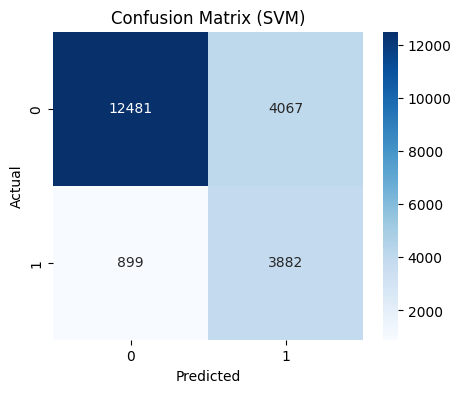

In [ ]:
# Модель SVM с линейным ядром
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)

# Обучаем на тренировочной выборке
svm_model.fit(X_train, y_train)

# Предсказания на валидационной выборке
y_val_pred_svm = svm_model.predict(X_val)

# Метрики на валидации
val_acc_svm = accuracy_score(y_val, y_val_pred_svm)
val_f1_svm = f1_score(y_val, y_val_pred_svm)

print("Validation results (SVM):")
print("Accuracy:", round(val_acc_svm, 4))
print("F1-score:", round(val_f1_svm, 4))

# Предсказания на тестовой выборке
y_test_pred_svm = svm_model.predict(X_test_reduced)

# Метрики на тесте
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
test_f1_svm = f1_score(y_test, y_test_pred_svm)

print("\nTest results (SVM):")
print("Accuracy:", round(test_acc_svm, 4))
print("F1-score:", round(test_f1_svm, 4))

# Classification report
print("\nClassification report (SVM):")
print(classification_report(y_test, y_test_pred_svm))

# Матрица ошибок
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

**Анализ результатов SVM**

Accuracy ~0.77: модель правильно предсказывает около 77% случаев в целом.

Для класса 0 (нет дождя) метрики качества выше: precision = 0.93, recall = 0.75, f1-score = 0.83. Для класса 1 (дождь): recall = 0.81 (модель хорошо находит большинство случаев дождя), но precision = 0.49 (много ложных срабатываний, когда дождь предсказан, но его нет). f1-score = 0.61 ниже, чем для класса 0, что ожидаемо при дисбалансе классов.

Матрица ошибок подтверждает это распределение.

**Подбор гиперпараметров SVM**

У метода опорных векторов SVM есть несколько ключевых гиперпараметров, влияющих на качество и скорость обучения, я попробую подобрать `C` (параметр регуляризации), который контролирует баланс между максимизацией ширины разделяющей гиперплоскости и минимизацией ошибок на обучающей выборке. Малые значения C делают модель более гладкой и склонной к недообучению, большие значения C уменьшают штраф за ошибки и могут приводить к переобучению.

In [ ]:
# Берем также половину тренировочной выборки для ускоренного подбора
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.5,
    stratify=y_train,
    random_state=42
)

# Список вариантов гиперпараметра C
C_values = [0.01, 0.1, 1, 10]

results_svm = []

for C in C_values:
    model = SVC(
        kernel='linear',
        class_weight='balanced',
        C=C,
        random_state=42
    )
    model.fit(X_train_small, y_train_small)
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    results_svm.append({'C': C, 'accuracy': acc, 'f1': f1})

results_svm_df = pd.DataFrame(results_svm)
results_svm_df.sort_values(by='f1', ascending=False)


,C,accuracy,f1
0,0.01,0.786580,0.612833
1,0.10,0.776155,0.609455
2,1.00,0.761924,0.600985
3,10.00,0.759773,0.599821


Наибольший F1-score и Accuracy наблюдаются при C = 0.01: F1 = 0.6128, Accuracy = 0.7866. При увеличении C метрики постепенно снижаются.

Для финального обучения и проверки на тестовой выборке выбираем C = 0.01, так как этот вариант обеспечивает наилучшее сочетание точности и способности модели правильно классифицировать редкий класс.


Test results (SVM, final):
Accuracy: 0.7917
F1-score: 0.623

Classification report (SVM, final):
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     16548
           1       0.52      0.77      0.62      4781

    accuracy                           0.79     21329
   macro avg       0.72      0.78      0.74     21329
weighted avg       0.83      0.79      0.80     21329



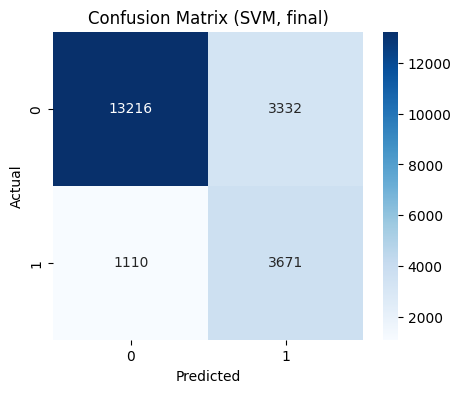

In [ ]:
# SVM с лучшим C
svm = SVC(
    kernel='linear',
    C=0.01,
    class_weight='balanced',
    random_state=42
)

svm.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_test_pred_svm = svm.predict(X_test_reduced)

# Метрики качества
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
test_f1_svm = f1_score(y_test, y_test_pred_svm)

print("Test results (SVM, final):")
print("Accuracy:", round(test_acc_svm, 4))
print("F1-score:", round(test_f1_svm, 4))

# Classification report
print("\nClassification report (SVM, final):")
print(classification_report(y_test, y_test_pred_svm))

# Матрица ошибок
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM, final)")
plt.show()


Результаты на тестовой выборке:

Accuracy: 0.7917
F1-score: 0.623

Подбор гиперпараметра C помог немного улучшить метрики, хотя обучение модели заняло значительное время.

## 5. Сравнение моделей

Логистическая регрессия: Accuracy 0.7927, f1-score (дождь) 0.6249, Recall (дождь) 0.77, Precision (дождь) 0.52

SVM: Accuracy 0.7917, f1-score (дождь) 0.6230, Recall (дождь) 0.77, Precision (дождь) 0.52

Обе модели показывают примерно схожую точность (79%) и f1-score (0.62), у SVM метрики совсем немного ниже. По классу дождя recall (0.77) и precision тоже одинаковый (0.52). Это подтверждает, что дисбаланс классов всё ещё ограничивает точность предсказания. Логистическая регрессия обучается быстрее, чем SVM с линейным ядром, на большом числе признаков (63).

Итог: обе модели обеспечивают базовый уровень предсказаний, хотя и не самый хороший. Для этой задачи логистическая регрессия дает сопоставимые результаты, но обучается значительно быстрее и проще интерпретируется.

## Вывод

В ходе работы были выполнены все задачи, использованы логистическая регрессия и метод опорных векторов (SVM) для предсказания дождя. Данные были дополнительно обработаны. В целом обе модели обеспечивают стабильное качество предсказаний, логистическая регрессия проще и быстрее, SVM немного ресурсозатратнее. Для обеих моделей проведен ручной подбор основных гиперпараметров. Результаты показали, что небольшие изменения параметров могут улучшить метрики. Дисбаланс классов заметно влияет на precision, поэтому модели чаще ошибаются в сторону ложноположительных предсказаний дождя.